In [1]:
# import duckdb
# import pandas as pd
# import matplotlib.pyplot as plt

# # Connect to DuckDB database
# conn = duckdb.connect("database/database.duckdb")

# # Query average water temperature by station type
# query = """
# SELECT 
#     s.station_type,
#     r.result_unit,
#     COUNT(r.result_pk) AS num_temp_results,
#     AVG(r.result_value) AS avg_water_temp,
#     MIN(r.result_value) AS min_water_temp,
#     MAX(r.result_value) AS max_water_temp
# FROM station AS s
# JOIN activity AS a
#     ON s.station_id = a.station_id
# JOIN result AS r
#     ON a.activity_pk = r.activity_pk
# JOIN characteristic AS c
#     ON r.characteristic_id = c.characteristic_id
# WHERE c.characteristic_name = 'Temperature, water'
#   AND r.result_value IS NOT NULL
# GROUP BY 
#     s.station_type,
#     r.result_unit
# ORDER BY avg_water_temp DESC;
# """

# df = conn.execute(query).df()

# df.head()

ModuleNotFoundError: No module named 'duckdb'

In [ ]:
# # Plot the query result
# fig, ax = plt.subplots(figsize=(9, 5))

# ax.barh(df["station_type"], df["avg_water_temp"])

# ax.set_xlabel("Average Water Temperature")
# ax.set_ylabel("Station Type")
# ax.set_title("Average Water Temperature by Station Type")

# plt.tight_layout()
# plt.show()

In [ ]:
# # Show the number of records
# fig, ax = plt.subplots(figsize=(9, 5))

# ax.barh(df["station_type"], df["avg_water_temp"])

# for i, row in df.iterrows():
#     ax.text(
#         row["avg_water_temp"],
#         i,
#         f" n={row['num_temp_results']}",
#         va="center"
#     )

# ax.set_xlabel("Average Water Temperature")
# ax.set_ylabel("Station Type")
# ax.set_title("Average Water Temperature by Station Type")

# plt.tight_layout()
# plt.show()

In [ ]:
# # Average water temperature by station
# query = """
# SELECT 
#     s.station_id,
#     s.station_name,
#     s.station_type,
#     r.result_unit,
#     COUNT(r.result_pk) AS num_temp_results,
#     AVG(r.result_value) AS avg_water_temp,
#     MIN(r.result_value) AS min_water_temp,
#     MAX(r.result_value) AS max_water_temp
# FROM station AS s
# JOIN activity AS a
#     ON s.station_id = a.station_id
# JOIN result AS r
#     ON a.activity_pk = r.activity_pk
# JOIN characteristic AS c
#     ON r.characteristic_id = c.characteristic_id
# WHERE c.characteristic_name = 'Temperature, water'
#   AND r.result_value IS NOT NULL
# GROUP BY 
#     s.station_id,
#     s.station_name,
#     s.station_type,
#     r.result_unit
# HAVING COUNT(r.result_pk) >= 5
# ORDER BY avg_water_temp DESC
# LIMIT 20;
# """

# temp_by_station = conn.execute(query).df()

# temp_by_station.head()

In [ ]:
# # Plot the resulting query
# fig, ax = plt.subplots(figsize=(10, 7))

# ax.barh(
#     temp_by_station["station_id"],
#     temp_by_station["avg_water_temp"]
# )

# ax.invert_yaxis()
# ax.set_xlabel("Average Water Temperature")
# ax.set_ylabel("Station ID")
# ax.set_title("Top 20 Stations by Average Water Temperature")

# plt.tight_layout()
# plt.show()

## Visualization 2: Number of Results by Characteristic

In [ ]:
# query = """
# SELECT 
#     c.characteristic_name,
#     COUNT(r.result_pk) AS num_results
# FROM result AS r
# JOIN characteristic AS c
#     ON r.characteristic_id = c.characteristic_id
# GROUP BY c.characteristic_name
# ORDER BY num_results DESC
# LIMIT 15;
# """

# char_counts = conn.execute(query).df()

# char_counts.head()

In [ ]:
# fig, ax = plt.subplots(figsize=(10, 7))

# ax.barh(
#     char_counts["characteristic_name"],
#     char_counts["num_results"]
# )

# ax.invert_yaxis()
# ax.set_xlabel("Number of Results")
# ax.set_ylabel("Characteristic")
# ax.set_title("Top 15 Most Frequently Measured Water Quality Characteristics")

# plt.tight_layout()
# plt.show()

## Visualization 3: Water temperature over time

In [ ]:
# query = """
# SELECT 
#     a.activity_start_date,
#     r.result_value AS water_temp,
#     r.result_unit
# FROM activity AS a
# JOIN result AS r
#     ON a.activity_pk = r.activity_pk
# JOIN characteristic AS c
#     ON r.characteristic_id = c.characteristic_id
# WHERE c.characteristic_name = 'Temperature, water'
#   AND r.result_value IS NOT NULL
#   AND a.activity_start_date IS NOT NULL
# ORDER BY a.activity_start_date;
# """

# temp_time = conn.execute(query).df()

# temp_time["activity_start_date"] = pd.to_datetime(temp_time["activity_start_date"])

# temp_time.head()

In [ ]:
# # Aggregate by year
# temp_time["year"] = temp_time["activity_start_date"].dt.year

# annual_temp = (
#     temp_time
#     .groupby("year", as_index=False)
#     .agg(
#         avg_water_temp=("water_temp", "mean"),
#         num_results=("water_temp", "count")
#     )
# )

# annual_temp.head()

In [ ]:
# # Plot the result
# fig, ax = plt.subplots(figsize=(10, 5))

# ax.plot(
#     annual_temp["year"],
#     annual_temp["avg_water_temp"],
#     marker="o"
# )

# ax.set_xlabel("Year")
# ax.set_ylabel("Average Water Temperature")
# ax.set_title("Average Water Temperature Over Time")

# plt.tight_layout()
# plt.show()

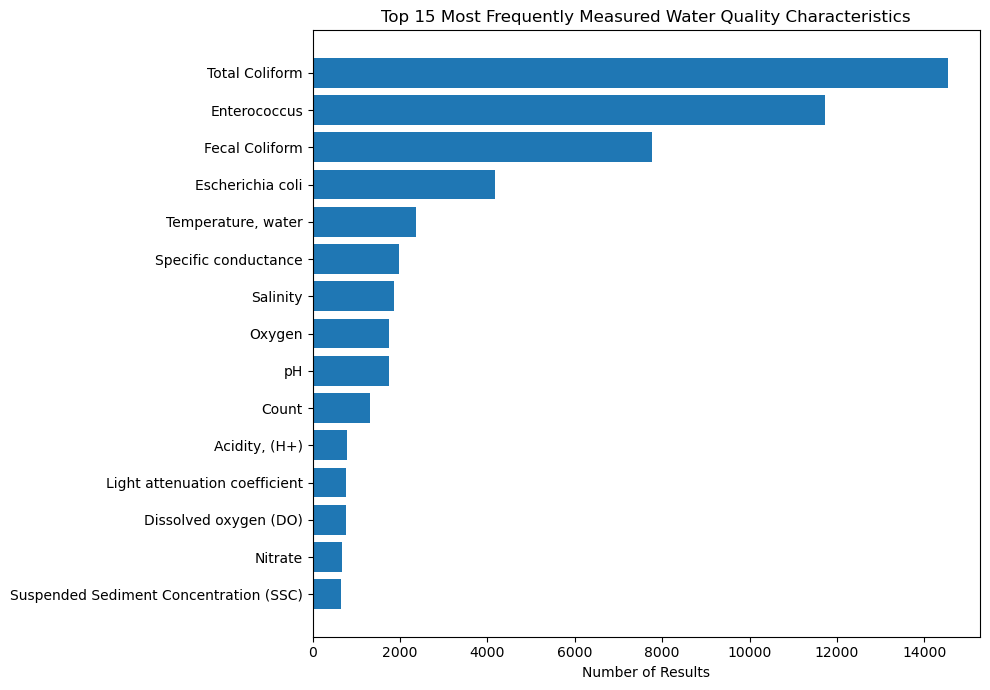

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

char_counts = pd.read_csv("data_viz/top_characteristics.csv")

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    char_counts["characteristic_name"],
    char_counts["num_results"]
)

ax.invert_yaxis()
ax.set_xlabel("Number of Results")
ax.set_ylabel("")
ax.set_title("Top 15 Most Frequently Measured Water Quality Characteristics")

plt.tight_layout()
plt.show()